# Task 2: Bayesian Change Point Modeling of Brent Oil Log Returns

**Birhan Energies - Change Point Analysis Project**

This notebook builds a single change-point Bayesian model in PyMC to detect
a structural break in Brent oil log returns, checks convergence, and
associates the detected change point with researched events.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline


g++ not available, if using conda: `conda install gxx`


## 1. Load Processed Data

In [2]:
df = pd.read_csv('../data/processed_brent_prices.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna(subset=['LogReturn']).reset_index(drop=True)

events = pd.read_csv('../data/events.csv')
events['Date'] = pd.to_datetime(events['Date'])

print(f"Log return series length: {len(df)}")
df.head()


Log return series length: 9010


,Date,Price,LogPrice,LogReturn
0,1987-05-21,18.45,2.915064,-0.009709
1,1987-05-22,18.55,2.920470,0.005405
2,1987-05-25,18.60,2.923162,0.002692
3,1987-05-26,18.63,2.924773,0.001612
4,1987-05-27,18.60,2.923162,-0.001612


## 2. Build the Bayesian Change Point Model

We model the log returns as coming from a Normal distribution whose mean
switches at an unknown point `tau`. `tau` has a discrete uniform prior over
all valid time indices. We use a shared `sigma` for simplicity in this core
model (a natural extension is to let sigma also switch, to capture the
volatility regime shifts we saw in the EDA).

In [3]:
returns = df['LogReturn'].values
n = len(returns)
idx = np.arange(n)

with pm.Model() as cp_model:
    tau = pm.Categorical('tau', p=np.ones(n) / n)

    mu_1 = pm.Normal('mu_1', mu=0, sigma=0.05)
    mu_2 = pm.Normal('mu_2', mu=0, sigma=0.05)
    sigma = pm.HalfNormal('sigma', sigma=0.05)

    mu = pm.math.switch(tau >= idx, mu_1, mu_2)

    likelihood = pm.Normal('likelihood', mu=mu, sigma=sigma, observed=returns)


## 3. Run the Sampler

Note: `tau` is discrete, so PyMC will use a compound step (Metropolis for
`tau`, NUTS for the continuous parameters). This is slower than a pure NUTS
model but is the standard approach for change point detection. With ~9000
observations this may take several minutes — this is expected, not an
error.

In [4]:
with cp_model:
    step_tau = pm.CategoricalGibbsMetropolis(vars=[tau])
    step_cont = pm.NUTS(vars=[mu_1, mu_2, sigma], target_accept=0.95)
    trace = pm.sample(2000, tune=2000, chains=4, cores=1, step=[step_tau, step_cont], return_inferencedata=True, random_seed=42)


Sequential sampling (4 chains in 1 job)


CompoundStep


>CategoricalGibbsMetropolis: [tau]


>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 31 seconds.


There were 15 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## 4. Check Convergence

In [5]:
summary = az.summary(trace, var_names=['tau', 'mu_1', 'mu_2', 'sigma'])
summary


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,6e+03,3e+03,210,8900,213,351,1.02,330,130
mu_1,6e-05,0.001,-0.00082,0.00089,1676,1648,1.01,2.4e-05,0.00014
mu_2,0.0006,0.002,-0.0011,0.004,37,28,1.08,0.00029,0.0011
sigma,0.025536,0.000191,0.025,0.026,3553,3788,1.00,3.2e-06,2.3e-06


**How to read this:** r_hat values close to 1.0 (ideally < 1.01) indicate
the chains have converged to the same distribution. If r_hat is notably
above 1.01 for any parameter, the model needs more samples/tuning before
its results can be trusted.

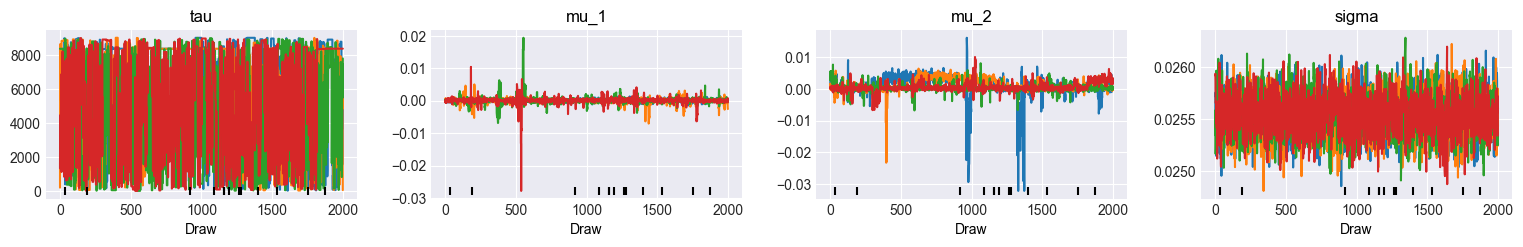

In [6]:
az.plot_trace(trace, var_names=['tau', 'mu_1', 'mu_2', 'sigma'])
plt.tight_layout()
plt.savefig('../data/cp_trace_plot.png', dpi=150)
plt.show()


## 5. Identify the Change Point

Most probable tau index: 8358
Corresponding date: 2020-04-21


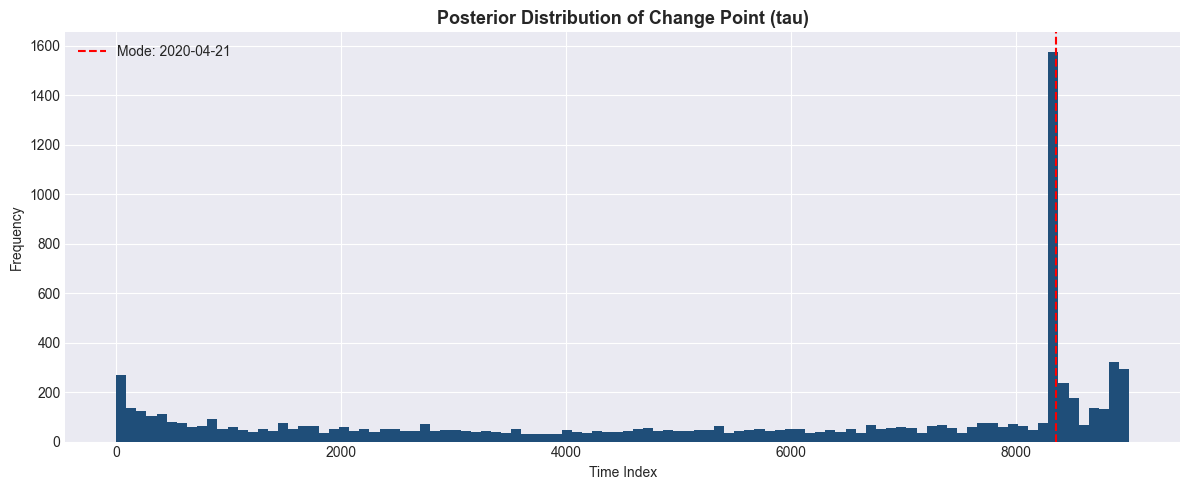

In [7]:
tau_samples = trace.posterior['tau'].values.flatten()
tau_mode = int(pd.Series(tau_samples).mode()[0])
tau_date = df.iloc[tau_mode]['Date']

print(f"Most probable tau index: {tau_mode}")
print(f"Corresponding date: {tau_date.date()}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(tau_samples, bins=100, color='#1f4e79')
ax.axvline(tau_mode, color='red', linestyle='--', label=f'Mode: {tau_date.date()}')
ax.set_title('Posterior Distribution of Change Point (tau)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Index')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('../data/tau_posterior.png', dpi=150)
plt.show()


**Interpreting the shape:** a sharp, narrow peak in this histogram
indicates high certainty about exactly when the change occurred. A wide or
multi-modal distribution suggests the model is uncertain, or that there may
genuinely be more than one structural break in the series (motivating a
multiple change-point extension).

## 5b. Multiple Candidate Change Points

A single change-point model forces the posterior to pick one break, even
if the true series has several. Rather than reporting only the single mode,
we bin the tau posterior and report the top candidate regions by posterior
mass. This gives a more honest picture: with 35 years of data and multiple
known historical shocks, we expect the posterior to spread its mass across
more than one plausible break, and each of those is worth reporting as a
hypothesis rather than discarding in favor of one "winner".

In [8]:
n_bins = 60
counts, bin_edges = np.histogram(tau_samples, bins=n_bins, range=(0, n - 1))
bin_centers = ((bin_edges[:-1] + bin_edges[1:]) / 2).astype(int)

top_bin_order = np.argsort(counts)[::-1]
candidates = []
used_indices = []
for b in top_bin_order:
    idx_center = bin_centers[b]
    if any(abs(idx_center - u) < n // 20 for u in used_indices):
        continue
    used_indices.append(idx_center)
    candidates.append((idx_center, counts[b] / len(tau_samples)))
    if len(candidates) == 3:
        break

print('Top candidate change points (index, approx posterior mass share, date):')
for idx_c, mass in candidates:
    date_c = df.iloc[min(idx_c, len(df)-1)]['Date'].date()
    print(f'  index={idx_c:5d}  mass={mass:.1%}  date={date_c}')


Top candidate change points (index, approx posterior mass share, date):
  index= 8333  mass=20.4%  date=2020-03-13
  index= 8933  mass=6.3%  date=2022-07-27
  index=   75  mass=4.7%  date=1987-09-04


Mean log return BEFORE tau: 0.000060
Mean log return AFTER tau:  0.000649
Probability that the mean return increased after tau: 63.19%


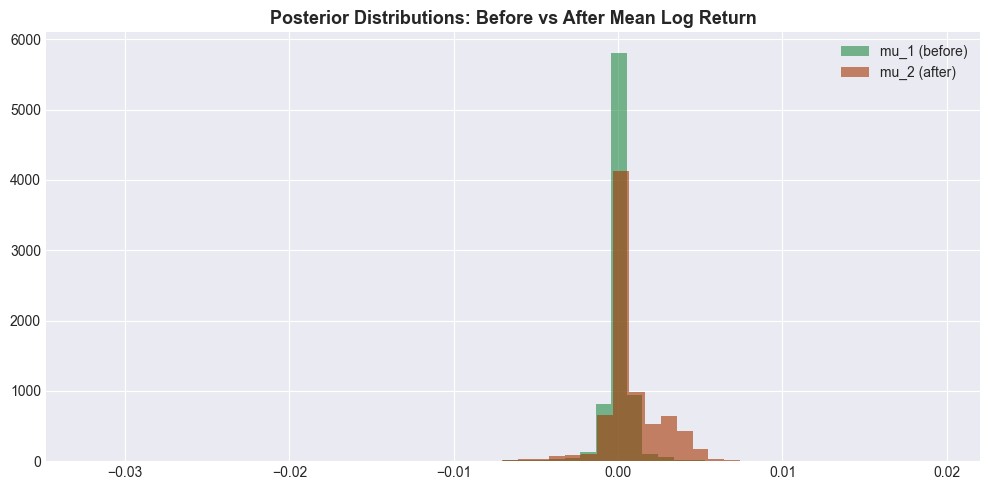

In [9]:
mu_1_samples = trace.posterior['mu_1'].values.flatten()
mu_2_samples = trace.posterior['mu_2'].values.flatten()

mu_1_mean, mu_2_mean = mu_1_samples.mean(), mu_2_samples.mean()
pct_change = (mu_2_mean - mu_1_mean) / abs(mu_1_mean) * 100 if mu_1_mean != 0 else float('nan')

prob_increase = (mu_2_samples > mu_1_samples).mean()

print(f"Mean log return BEFORE tau: {mu_1_mean:.6f}")
print(f"Mean log return AFTER tau:  {mu_2_mean:.6f}")
print(f"Probability that the mean return increased after tau: {prob_increase:.2%}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(mu_1_samples, bins=50, alpha=0.6, label='mu_1 (before)', color='#238b45')
ax.hist(mu_2_samples, bins=50, alpha=0.6, label='mu_2 (after)', color='#a63603')
ax.set_title('Posterior Distributions: Before vs After Mean Log Return', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/before_after_posteriors.png', dpi=150)
plt.show()


## 7. Associate Change Point with Researched Events

In [10]:
events['DaysFromTau'] = (events['Date'] - tau_date).dt.days
events_sorted = events.reindex(events['DaysFromTau'].abs().sort_values().index)

print(f"Detected change point date: {tau_date.date()}\n")
print("Closest researched events (sorted by proximity):")
events_sorted[['Date', 'Event', 'Category', 'DaysFromTau']].head(5)


Detected change point date: 2020-04-21

Closest researched events (sorted by proximity):


,Date,Event,Category,DaysFromTau
13,2020-04-20,WTI futures turn negative,Market Event,-1
12,2020-03-08,Saudi-Russia oil price war begins,OPEC Policy,-44
11,2019-09-14,Attack on Saudi Aramco facilities,Conflict,-220
14,2022-02-24,Russia invades Ukraine,Conflict,674
10,2018-05-08,US withdraws from Iran nuclear deal,Sanctions,-714


**Write your hypothesis here** once you see which event(s) are closest in
time to the detected `tau`. Remember: proximity is suggestive, not proof —
frame this as "the detected change point coincides with X, suggesting a
plausible link" rather than a definitive causal claim (see the
correlation-vs-causation discussion in `docs/analysis_workflow.md`).

## 8. Save Model Results for Dashboard (Task 3)

In [11]:
results = {
    'tau_index': int(tau_mode),
    'tau_date': str(tau_date.date()),
    'mu_1_mean': float(mu_1_mean),
    'mu_2_mean': float(mu_2_mean),
    'pct_change': float(pct_change),
    'prob_increase': float(prob_increase),
}

import json
with open('../data/change_point_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Saved change_point_results.json")
results


Saved change_point_results.json


{'tau_index': 8358,
 'tau_date': '2020-04-21',
 'mu_1_mean': 5.997651560148816e-05,
 'mu_2_mean': 0.000649109719206008,
 'pct_change': 982.2731409056751,
 'prob_increase': 0.631875}